# TASK 3: Car Price Prediction with Machine Learning
Collect car-related features like brand goodwill, horsepower, mileage, etc.

Train a regression model to predict car prices based on these features.

Handle data preprocessing, feature engineering, and model evaluation.

Use Python libraries like Pandas, Scikit-learn, and Matplotlib for the workflow.

Understand real-world applications of machine learning in price prediction.

In [47]:
import numpy as numpy
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error ,r2_score

In [2]:
car_data = pd.read_csv("data/car data.csv")

In [3]:
df= pd.DataFrame(car_data)

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df["Transmission"].value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

In [6]:
df["Selling_type"].value_counts()

Selling_type
Dealer        195
Individual    106
Name: count, dtype: int64

In [7]:
df["Transmission"].value_counts()

Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

In [8]:
df["Car_Name"].value_counts()

Car_Name
city                   26
corolla altis          16
verna                  14
fortuner               11
brio                   10
                       ..
Hero Super Splendor     1
Hero Hunk               1
Hero  Ignitor Disc      1
Hero  CBZ Xtreme        1
Bajaj  ct 100           1
Name: count, Length: 98, dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


Text(0.5, 1.0, 'selling price distribution')

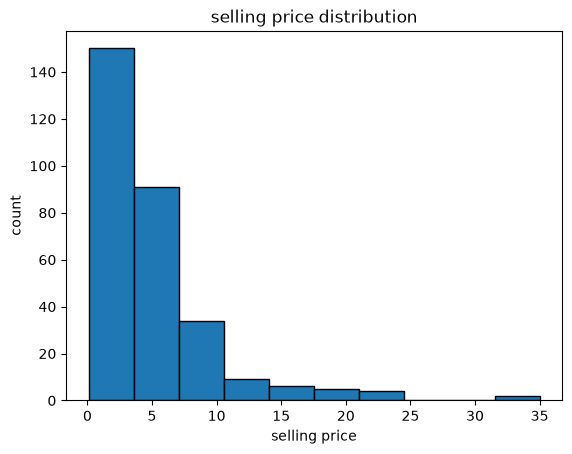

In [10]:
# plt.figure(fig_size=(10,5))
plt.hist(df["Selling_Price"], edgecolor='black')
plt.xlabel("selling price")
plt.ylabel("count")
plt.title("selling price distribution")

<Axes: xlabel='Year', ylabel='Selling_Price'>

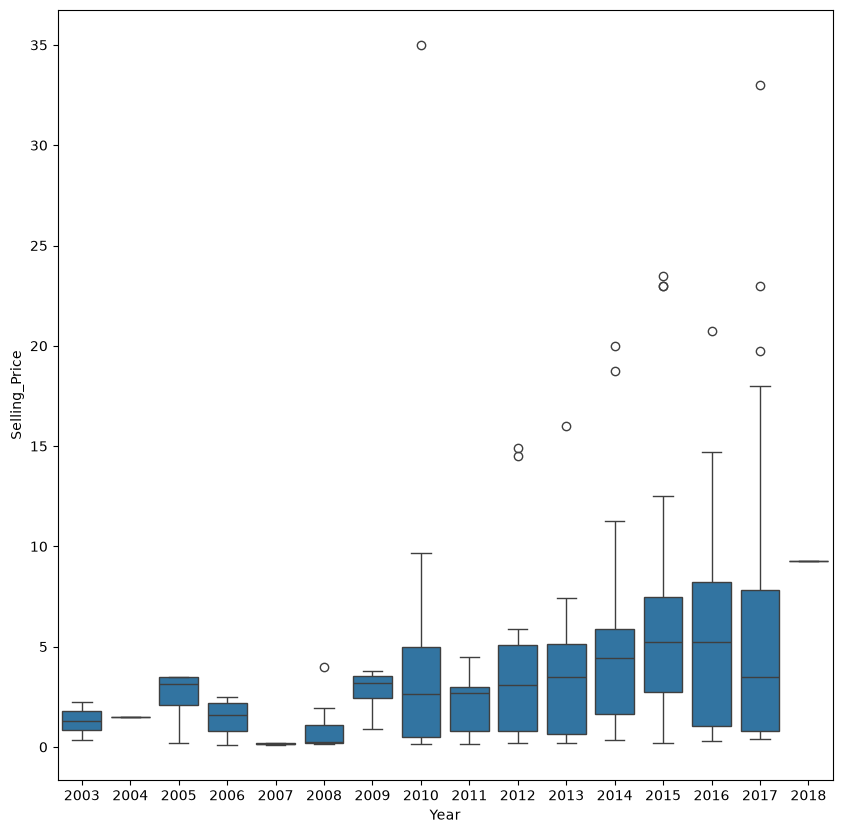

In [11]:
#boxplot
plt.figure(figsize=(10,10))
sns.boxplot(x="Year",y="Selling_Price",data=df)

In [12]:
encoder = OneHotEncoder(handle_unknown="ignore")
encoded_raw_data= encoder.fit_transform(df[['Fuel_Type','Selling_type','Transmission']]).toarray()
encoded_data = pd.DataFrame(encoded_raw_data , columns =encoder.get_feature_names_out(['Fuel_Type','Selling_type','Transmission']))
encoded_data

,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Dealer,Selling_type_Individual,Transmission_Automatic,Transmission_Manual
0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...
296,0.0,1.0,0.0,1.0,0.0,0.0,1.0
297,0.0,0.0,1.0,1.0,0.0,0.0,1.0
298,0.0,0.0,1.0,1.0,0.0,0.0,1.0
299,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [13]:
car_type_encoded = df["Car_Name"].value_counts().to_dict()
df["car_name_freq"] = df["Car_Name"].map(car_type_encoded)

In [14]:
df.drop(columns=["Car_Name","Fuel_Type","Selling_type","Transmission"], inplace=True)
df= pd.concat([df,encoded_data],axis=1)

In [15]:
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,car_name_freq,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Dealer,Selling_type_Individual,Transmission_Automatic,Transmission_Manual
0,2014,3.35,5.59,27000,0,4,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,2013,4.75,9.54,43000,0,6,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,2017,7.25,9.85,6900,0,9,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,2011,2.85,4.15,5200,0,4,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,2014,4.60,6.87,42450,0,5,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     301 non-null    int64  
 1   Selling_Price            301 non-null    float64
 2   Present_Price            301 non-null    float64
 3   Driven_kms               301 non-null    int64  
 4   Owner                    301 non-null    int64  
 5   car_name_freq            301 non-null    int64  
 6   Fuel_Type_CNG            301 non-null    float64
 7   Fuel_Type_Diesel         301 non-null    float64
 8   Fuel_Type_Petrol         301 non-null    float64
 9   Selling_type_Dealer      301 non-null    float64
 10  Selling_type_Individual  301 non-null    float64
 11  Transmission_Automatic   301 non-null    float64
 12  Transmission_Manual      301 non-null    float64
dtypes: float64(9), int64(4)
memory usage: 30.7 KB


Text(0.5, 1.0, 'correlation heatmap')

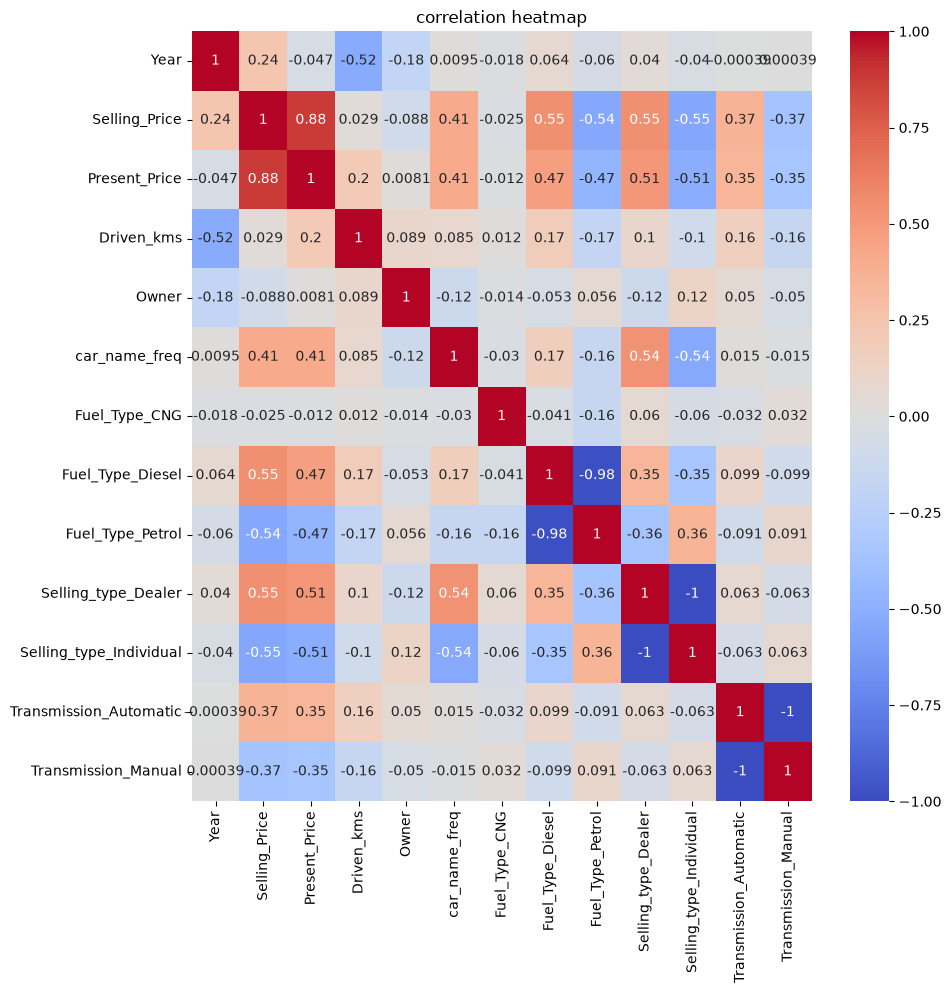

In [17]:
# correlation heatmap 

corr = df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr,annot =True , cmap="coolwarm")
plt.title("correlation heatmap")


In [18]:
df= df.drop(columns=["Driven_kms","Owner","Fuel_Type_CNG"])

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Year                     301 non-null    int64  
 1   Selling_Price            301 non-null    float64
 2   Present_Price            301 non-null    float64
 3   car_name_freq            301 non-null    int64  
 4   Fuel_Type_Diesel         301 non-null    float64
 5   Fuel_Type_Petrol         301 non-null    float64
 6   Selling_type_Dealer      301 non-null    float64
 7   Selling_type_Individual  301 non-null    float64
 8   Transmission_Automatic   301 non-null    float64
 9   Transmission_Manual      301 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 23.6 KB


<Figure size 1000x800 with 0 Axes>

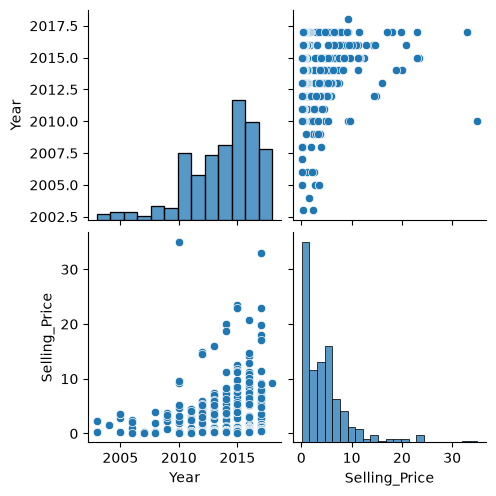

In [20]:
plt.figure(figsize=(10,8))
sns.pairplot(df[["Year", "Selling_Price"]])

In [23]:
x = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [35]:
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.2 , random_state=42)

In [36]:
scaler = StandardScaler()

In [39]:
x_train = scaler.fit_transform(x_train)
x_test= scaler.transform(x_test)

In [48]:
model = RandomForestRegressor(random_state=42)


In [49]:
model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [50]:
y_pred = model.predict(x_test)

In [51]:
compare = pd.DataFrame({"actual": y_test ,"preducted":y_pred})
compare 

,actual,preducted
177,0.35,0.465600
289,10.11,9.858017
228,4.95,5.056500
198,0.15,0.225500
60,6.95,7.840767
...,...,...
234,5.50,4.832467
296,9.50,9.009579
281,2.10,2.906400
285,7.40,6.284767


In [52]:
mse = mean_squared_error(y_test,y_pred)
mse

0.7182981408638688

In [53]:
r2_score(y_test,y_pred)

0.9688178895468801